# **Customer Churn Prediction**

Customer churn is a major challenge for subscription based businesses.
The goal of this project is to predict which customers are likely to churn
and identify the key factors driving churn to support targeted retention strategies.

In [102]:
#Necessary Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score



In [103]:
#Load Data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [104]:
df['Churn'] = df['Churn'].astype(str).str.strip()
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [105]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()
#Churn = 1 means customer left, 0 means stayed

,count
Churn,
0,5174
1,1869


In [106]:
#Drop customer ID
df = df.drop('customerID', axis=1)

**Exploratory Data Analysis**

In [107]:
#Basic Dataset Information
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.265370
std,0.368612,24.559481,30.090047,0.441561
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,0.000000
50%,0.000000,29.000000,70.350000,0.000000
75%,0.000000,55.000000,89.850000,1.000000
max,1.000000,72.000000,118.750000,1.000000


In [108]:
#Convert Total Charges to a numeric datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

In [109]:
#Checking for Missing Values
missing = df.isnull().sum()
print(missing)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


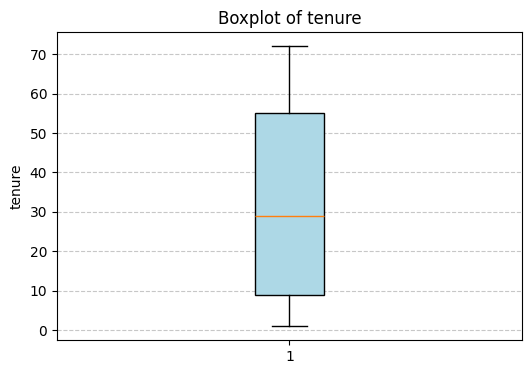

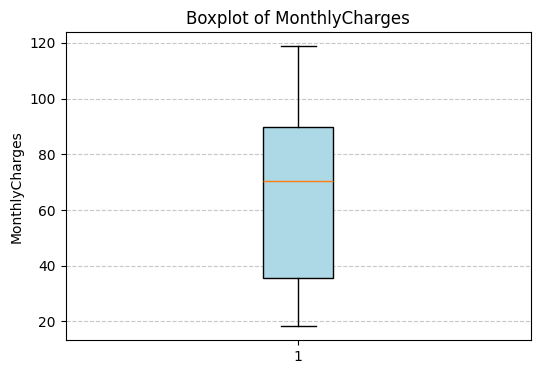

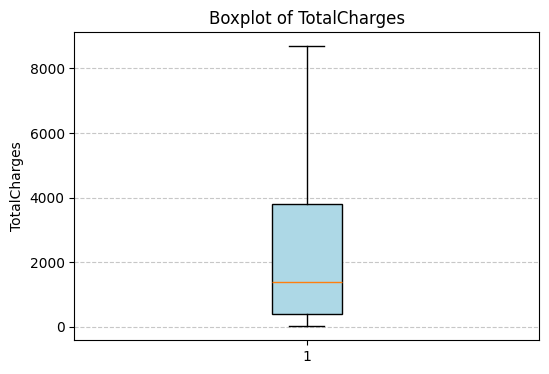

In [110]:
#Check for Outliers
for col in num_cols:
    plt.figure(figsize=(6,4))

    plt.boxplot(
        df[col],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue')
    )

    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

Total Charges has a large amount

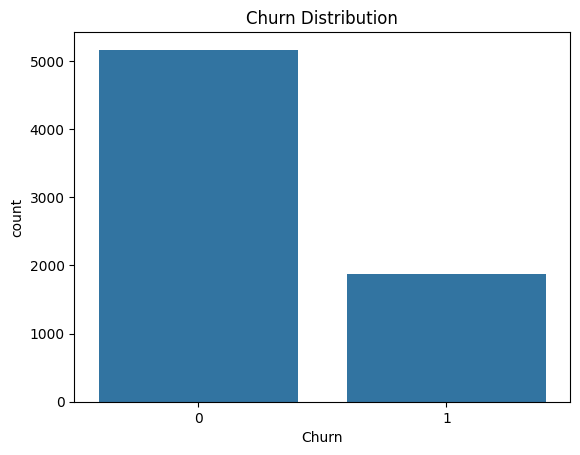

,proportion
Churn,
0,73.421502
1,26.578498


In [111]:
#Check Distribution of Target Variable, Churn
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

df['Churn'].value_counts(normalize=True) * 100

The churn dataset is imbalanced with a 26.5% churn rate. Because of this moderate imbalance, a stratified training/testing split will be used later on. Model evaluation must always consist of metrics other than accuracy, like F1 score, precision/recall, and ROC curves.

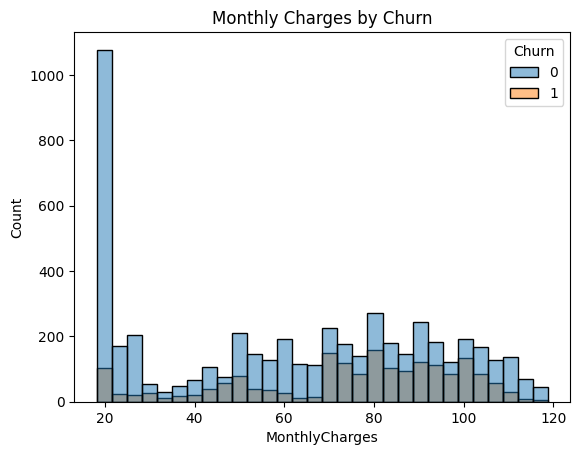

In [112]:
#Monthly Charges by Churn Class
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30)
plt.title("Monthly Charges by Churn")
plt.show()

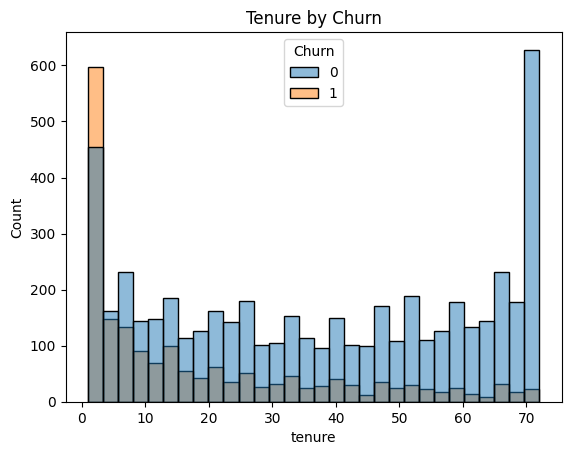

In [113]:
#Tenure by Churn Class
sns.histplot(data=df, x='tenure', hue='Churn',bins=30)
plt.title("Tenure by Churn")
plt.show()

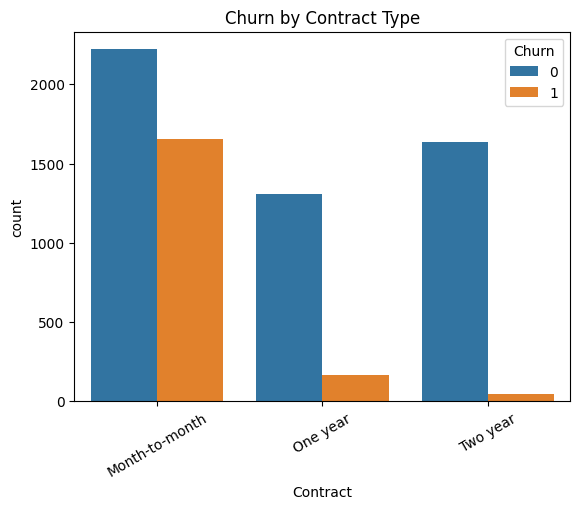

In [114]:
#Contract Type and Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.title("Churn by Contract Type")
plt.show()

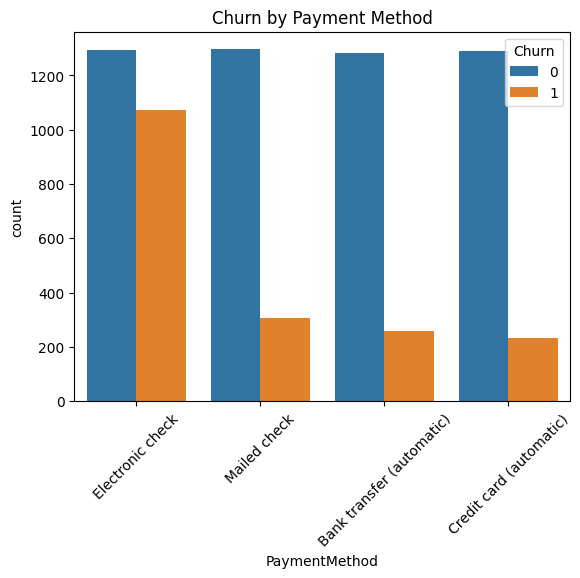

In [115]:
#Payment Method and Churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

**Data Preprocessing**

In [116]:
#Convert No internet service to No
#No internet service values were consolidated into 'No' to simplify feature representation and reduce redundancy
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols:
    df[col] = df[col].replace('No internet service', 'No')

In [117]:
#Separate X and Y
X = df.drop('Churn', axis=1)
y = df['Churn']

In [118]:
#Encode Categorical Variables
cat_cols = X.select_dtypes(include=['object']).columns

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [119]:
#Check
for col in X.columns:
    print(col)

SeniorCitizen
tenure
MonthlyCharges
TotalCharges
gender_Male
Partner_Yes
Dependents_Yes
PhoneService_Yes
MultipleLines_No phone service
MultipleLines_Yes
InternetService_Fiber optic
InternetService_No
OnlineSecurity_Yes
OnlineBackup_Yes
DeviceProtection_Yes
TechSupport_Yes
StreamingTV_Yes
StreamingMovies_Yes
Contract_One year
Contract_Two year
PaperlessBilling_Yes
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check


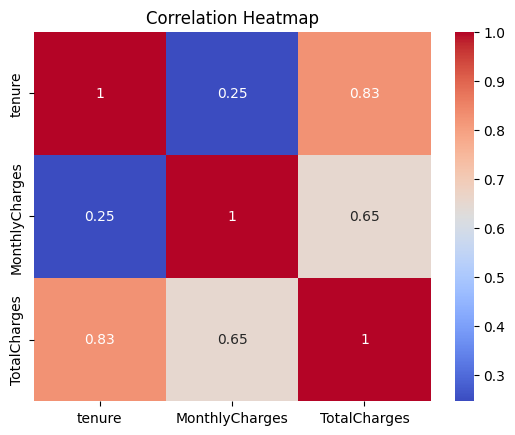

In [120]:
#Check for multicollinearity

corr_features = X[['tenure', 'MonthlyCharges', 'TotalCharges']]
sns.heatmap(corr_features.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

While tenure and TotalCharges are correlated, they represent duration and total cumulative spending. Since tree-based models are robust to multicollinearity, both features were retained.

**Modeling**

In [121]:
#Train Test Split
#Using stratified sampling to keep the same churn ratio as the original data in both the training and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [122]:
#Models
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    )
}

In [123]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.726368,0.490939,0.796791,0.607543,0.834909
1,Random Forest,0.785359,0.625000,0.481283,0.543807,0.821120


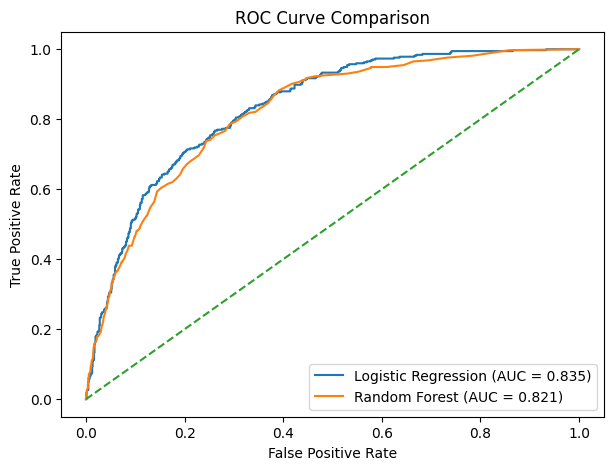

In [124]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(7,5))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [125]:
print(type(models["Random Forest"]))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [126]:
#Feature Importances
rf_model = models["Random Forest"]

rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'RF_Importance': rf_model.feature_importances_
}).sort_values(by='RF_Importance', ascending=False)

lr_pipeline = models["Logistic Regression"]
lr_model = lr_pipeline.named_steps['model']

lr_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'LR_Coefficient': lr_model.coef_[0]
})


lr_importances['LR_Abs'] = lr_importances['LR_Coefficient'].abs()
lr_importances = lr_importances.sort_values(by='LR_Abs', ascending=False)

rf_top3 = rf_importances.head(3)
lr_top3 = lr_importances.head(3)

print("Top 3 Random Forest Features:")
print(rf_top3)

print("\nTop 3 Logistic Regression Features:")
print(lr_top3[['Feature', 'LR_Coefficient']])

Top 3 Random Forest Features:
          Feature  RF_Importance
3    TotalCharges       0.175859
2  MonthlyCharges       0.168488
1          tenure       0.166417

Top 3 Logistic Regression Features:
                        Feature  LR_Coefficient
1                        tenure       -1.245221
2                MonthlyCharges       -0.846207
10  InternetService_Fiber optic        0.714694


**Interpretation**
While random forest achieved higher overall accuracy, logistic regression demonstrated significantly higher recall for churn prediction. This indicates that logistic regression is more effective at identifying customers at risk of churning, which is often more valuable in business settings where missing a churner is costly.

**Business Recommendations**
This analysis identified tenure, monthly charges, and fiber optic internet service as key drivers of customer churn. Customers with higher monthly charges and fiber optic plans were more likely to churn, while longer-tenured customers showed significantly lower churn risk. Based on these insights, the business should prioritize early customer engagement, implement targeted pricing strategies for high cost users, and investigate potential dissatisfaction among fiber optic customers. Also, deploying the model for proactive retention campaigns can help identify at risk customers and reduce overall churn.